## 1. 今日の量子コンピュータの問題

- Noisy Intermediate-Scale Quantum (NISQ) デバイス
    - 量子回路が深くなる（ゲート数が多くなる）ほど、誤差が大きくなる
    - 十分な量子ビット数ではない
- 量子デバイスは特別な量子ゲート演算しか用意されていない  
  Quantinuum H-series: , IBM Quantum:
- 超電導型量子デバイスでは特定の２量子ビット間の量子ビット演算しか用意されていない
- それぞれの量子デバイスに対して、量子ソフトウェアツールキットが用意されてる


### 1-1. TKETとは
- Quantum Software Development Kit
- TKETに実装されている回路最適化はC++で実装
- pythonモジュール　`pytket`で利用可能
- 最適化コンパイラ：　ユーザーフレンドリーな回路→量子デバイスで実行可能な回路に変換可能
    - Language-agnostic (多くの量子プログラミングフレームワーク(qiskit, Cirq, etc)をサポート)
    - Retagetable (多くの量子デバイス(IBM, Quantinuum, Amazon Braket(IonQ, Rigetti, IQM), Microsoft Azure Quantum(Quantinuum, IonQ, Rigetti) etc)をサポート)
    - Circuit Optimisation (量子計算時に生じるデバイスエラーの影響を最小化。デバイス依存＆デバイス非依存のものが実装)
    
<img src="./fig/tket1.png" width="750">



#### 参照
- [pytket ドキュメント](https://docs.quantinuum.com/tket/api-docs/)
- [pytket ユーザーガイド](https://docs.quantinuum.com/tket/user-guide/)
- [t|ket⟩ : A Retargetable Compiler for NISQ Devices](https://arxiv.org/abs/2003.10611)
- [TKET slack channel](https://join.slack.com/t/tketusers/shared_invite/zt-2aoan2s87-WDdZQeY2dbJQgAQE6O~3qg)

<img src="./fig/slack-qr.png" width="250">


### 1-2. pytketと拡張 pytket (python パッケージ)
Python 3.11,12で動作確認をしています。

|  パッケージ |  概要  |
| :---- | :---- |
|  pytket  |  TKETを利用するためのpython モジュール  ( available for python3.10 or higher )|
|  pytket-quantinuum  |  Quantinuumデバイス、エミュレータを利用するためのpytket-extension  |
|  pytket-qiskit  |  qiskit、IMBQデバイスを利用するためのpytket-extension  |
|  pytket-azure  |  Azure Quantumを利用するためのpytket-extension  |
|  pytket-braket  |  Amazon Braketを利用するためのpytket-extension  |
|  pytket-circ    |  Google circを利用するためのpytket-extension  |
|  pytket-qulacs  |  Qulacsシミュレータを利用するためのpytket-extension  |

<img src="./fig/tket2.png" width="850">

## 2. 量子回路を作成する　（より詳しい内容は２日目に行います）
ここでは IBMの量子デバイスやシュミレーションを利用できる`qiskit`と`TKET`でBell状態を作成する。

### 2-1. `qiskit`でBell状態を作成
$$ |\Psi\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$$

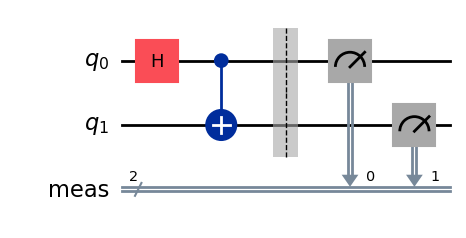

In [1]:
# qiskitを使って量子回路を作成するために必要なモジュールをインポート
from qiskit import QuantumCircuit

# 2 qubit から成る空の量子回路を作成
qs_bell = QuantumCircuit(2)

#ユニタリゲートを回路に追加。qubitのindexは0,1,...
qs_bell.h(0) #q_0に作用するHadamard gateを追加
qs_bell.cx(0,1) #q_0を制御ビット、q_1を標的ビットとするCNOT gateを回路に追加

#(パウリZの基底での)測定
qs_bell.measure_all()

#回路の描画
qs_bell.draw(output='mpl')

In [2]:
#from qiskit.tools.visualization import circuit_drawer
#circuit_drawer(qs_bell, output='mpl')

### 2-2. IBMが提供しているローカルシミュレータで計算

In [3]:
from qiskit_aer import Aer #量子回路を実行するシミュレータを利用するために必要
from qiskit.visualization import plot_histogram #量子計算では最後に測定を行うが、測定結果を視覚化するために必要

In [4]:
#Aer.backends()

In [5]:
#シミュレータの指定
ibm_sim = Aer.get_backend('aer_simulator')

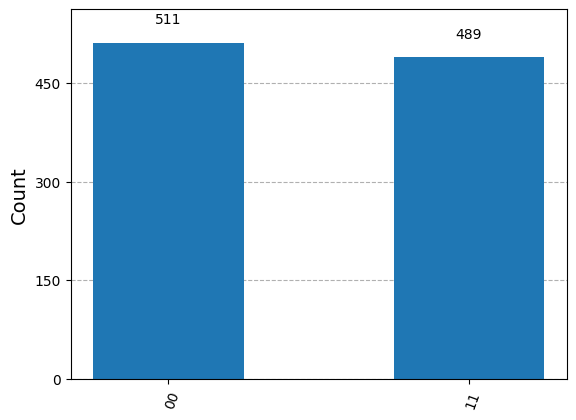

In [6]:
#回路の実行
handle = ibm_sim.run(qs_bell, shots=1000)
#実行した結果それぞれの測定結果が何回ずつ得られたか
counts = handle.result().get_counts()
plot_histogram(counts)

### 2-3. `TKET`でBell状態を作成

In [7]:
from pytket import Circuit
from pytket.circuit.display import render_circuit_jupyter

# 2 qubit から成る空の量子回路を作成
bell = Circuit(2)

#ユニタリゲートを回路に追加
bell.H(0).CX(0,1)

#(パウリZの基底での)測定
bell.measure_all()

#回路の描画
render_circuit_jupyter(bell)

Note：TKETの可視化では、可視化した量子回路の画像ファイルを出力できる。

### 2-4. `pytket-qiskit`でTKET 量子回路をIBMのローカルシミュレータで計算

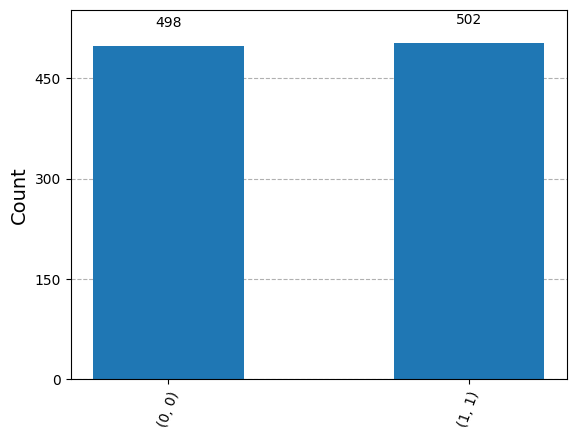

In [8]:
from pytket.extensions.qiskit import AerBackend

#シミュレータの指定
backend = AerBackend()

#回路の実行
handle = backend.process_circuit(bell, n_shots =1000)

#実行した結果、それぞれの測定結果が何回ずつ得られたかの取得
result_counts = backend.get_result(handle).get_counts()
#これをヒストグラム化
plot_histogram(result_counts)

### 2-5. `pytket-qiskit`でTKET 量子回路をIBMの量子デバイスで計算

IBM tokenの設定

In [2]:
path = 'key/ibm-token'
f = open(path)
ibm_token = f.read()
f.close()
#from pytket.extensions.qiskit.backends.config import set_ibmq_config
#set_ibmq_config(ibmq_api_token=ibm_token, instance=f"ibm-q/open/main")

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

# IBM QuantumのAPIキーを設定
QiskitRuntimeService.save_account(token=ibm_token, channel="ibm_quantum", overwrite=True)


In [4]:

service = QiskitRuntimeService()

service.backends()

[<IBMBackend('ibm_brisbane')>,
 <IBMBackend('ibm_kyiv')>,
 <IBMBackend('ibm_sherbrooke')>]

In [15]:
from pytket.extensions.qiskit import IBMQBackend
from pytket import Circuit
from pytket.circuit.display import render_circuit_jupyter

In [16]:
#利用可能なデバイスの確認

device = IBMQBackend.available_devices()

In [17]:
[dev.device_name for dev in device]

['ibm_brisbane', 'ibm_kyiv', 'ibm_sherbrooke']

In [18]:
#一番空いているデバイスの確認 (option)
#混んでいるデバイスほど待ち時間があるので...

print(service.least_busy(operational=True, simulator=False))

<IBMBackend('ibm_brisbane')>


In [19]:
#シミュレータを指定したのと全く同じように量子コンピュータを指定

# ibm_backend = AerBackend()
ibm_backend = IBMQBackend("ibm_brisbane")


### IBMの量子デバイス（ibm_kyoto）にジョブを実行

IBM Quantum device の情報  
https://quantum.ibm.com/services/resources

In [20]:
#上で指定したデバイスで回路を実行するために回路をコンパイルする。コンパイルされた回路は指定したバックエンドごとに変わります。
#(コンパイル前後の回路を図示して比較してみましょう！)
ibm_bell = ibm_backend.get_compiled_circuit(bell)
render_circuit_jupyter(ibm_bell)
render_circuit_jupyter(bell)

In [21]:
#指定したデバイス上で回路を実行
handle = ibm_backend.process_circuit(ibm_bell, n_shots =1000)
#result = ibm_backend.get_result(handle)
#counts = result.get_counts()
#plot_histogram(counts)

In [22]:
print(handle)

('czecngetp60g008hqm1g', 0, 2, 'null')


In [ ]:
#from pytket.backends import ResultHandle
#from pytket.extensions.qiskit import IBMQBackend
#ibm_backend = IBMQBackend("ibm_brisbane")

Counter({(1, 1): 490, (0, 0): 481, (1, 0): 19, (0, 1): 10})


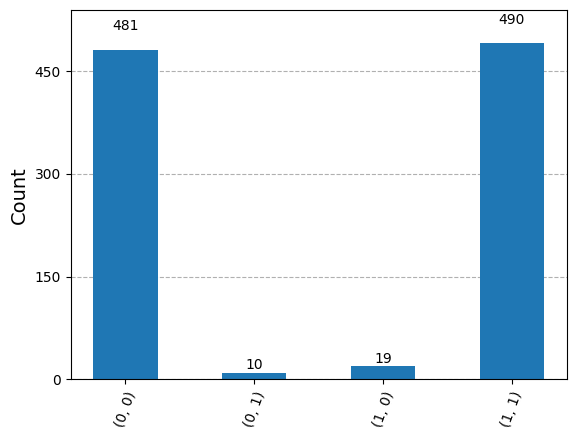

In [24]:
#handle = ('cz4jt2gh0kc00088wewg', 0, 2, 'null') #右辺に２つ上のセルの結果をペースト
#result = ibm_backend.get_result(handle)
#counts = result.get_counts()
#print(counts)
#from qiskit.visualization import plot_histogram
#plot_histogram(counts)

### 2-5. `pytket-quantinuum`でTKET 量子回路をQuantinuum エミュレータで計算

In [25]:
from pytket.extensions.quantinuum import QuantinuumAPIOffline
api = QuantinuumAPIOffline()

In [26]:
from pytket.extensions.quantinuum import QuantinuumBackend

#利用可能なバックエンドの確認
QuantinuumBackend.available_devices(api_handler = api)

[BackendInfo(name='QuantinuumBackend', device_name='H1-1', version='0.44.0', architecture=<tket::FullyConnected, nodes=20>, gate_set={<OpType.Measure: 66>, <OpType.Reset: 68>, <OpType.Rz: 36>, <OpType.PhasedX: 71>, <OpType.Barrier: 8>, <OpType.ZZMax: 73>, <OpType.ZZPhase: 76>, <OpType.ClassicalExpBox: 109>, <OpType.WASM: 14>, <OpType.SetBits: 15>, <OpType.CopyBits: 16>, <OpType.RangePredicate: 17>, <OpType.ExplicitPredicate: 18>, <OpType.ExplicitModifier: 19>, <OpType.MultiBit: 20>, <OpType.ClExpr: 116>, <OpType.TK2: 44>}, n_cl_reg=4000, supports_fast_feedforward=True, supports_reset=True, supports_midcircuit_measurement=True, all_node_gate_errors=None, all_edge_gate_errors=None, all_readout_errors=None, averaged_node_gate_errors=None, averaged_edge_gate_errors=None, averaged_readout_errors=None, misc={'wasm': True, 'batching': True, 'supported_languages': ['OPENQASM 2.0', 'QIR 1.0'], 'benchmarks': {'qv': {'date': '2024-04-04', 'value': 1048576.0}}, 'max_classical_register_width': 63, 

In [27]:
# 回路を実行するエミュレータの指定。ここではノイズのないローカルエミュレータを指定。
quantinuum_backend = QuantinuumBackend(device_name ='H1-1LE',api_handler = api)

# 回路を実行するためのコンパイル
quantinuum_bell = quantinuum_backend.get_compiled_circuit(bell)

#コンパイル前後での回路の違いを描画して確認
render_circuit_jupyter(quantinuum_bell)
render_circuit_jupyter(bell)

In [28]:
# 回路の実行 (左辺の変数に実行結果が格納される)
handle = quantinuum_backend.process_circuit(quantinuum_bell, n_shots=1000)
# 結果の取得
result = quantinuum_backend.get_result(handle)

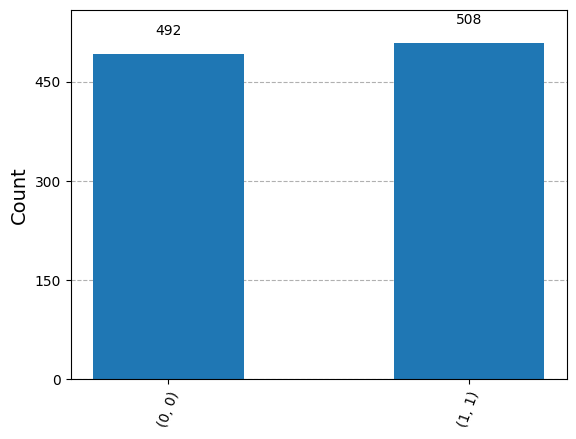

In [29]:
# それぞれの測定結果が得られた回数を取得
counts = result.get_counts()
plot_histogram(counts)

### 2-6. `pytket-qulacs`でTKET 量子回路をQulacsシミュレータで計算

In [30]:
from pytket.extensions.qulacs import QulacsBackend

#回路を実行するシミュレータとしてQslacsシミュレータを指定する
qulacs_backend = QulacsBackend()

In [31]:
qulacs_backend.backend_info

BackendInfo(name='QulacsBackend', device_name=None, version='0.39.0', architecture=None, gate_set={<OpType.Measure: 66>, <OpType.Barrier: 8>, <OpType.Z: 22>, <OpType.X: 23>, <OpType.Y: 24>, <OpType.S: 25>, <OpType.Sdg: 26>, <OpType.T: 27>, <OpType.Tdg: 28>, <OpType.H: 33>, <OpType.Rx: 34>, <OpType.Ry: 35>, <OpType.Rz: 36>, <OpType.U3: 37>, <OpType.U2: 38>, <OpType.U1: 39>, <OpType.CX: 45>, <OpType.CZ: 47>, <OpType.SWAP: 62>}, n_cl_reg=None, supports_fast_feedforward=False, supports_reset=False, supports_midcircuit_measurement=False, all_node_gate_errors=None, all_edge_gate_errors=None, all_readout_errors=None, averaged_node_gate_errors=None, averaged_edge_gate_errors=None, averaged_readout_errors=None, misc={})

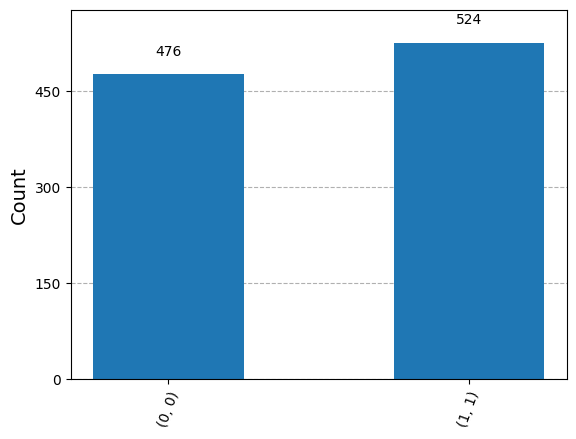

In [32]:
#回路の実行
handle = qulacs_backend.process_circuit(bell, n_shots =1000)
#測定結果の取得
result_counts = qulacs_backend.get_result(handle).get_counts()
plot_histogram(result_counts)

### GPU上でQulacsを利用している場合にも対応している


In [33]:
#from pytket.extensions.qulacs import QulacsGPUBackend
#qualcs_backend = QulacsGPUBackend()

#handle = qulacs_backend.process_circuit(bell, n_shots =1000)
#result_counts = qulacs_backend.get_result(handle).get_counts()
#plot_histogram(result_counts)

詳しくは
https://tket.quantinuum.com/extensions/pytket-qulacs/
を参照ください

### 2-7. `pytket-azure`でTKET 量子回路をMicrosoft Azure Quantum(有料)にある量子デバイスで計算が可能
本講演では詳細は割愛致しますが、Azure Quantum上でTKETをご利用になられたい方は下記のページを参考に設定をしてください。  
https://tket.quantinuum.com/extensions/pytket-azure/
または  
米澤(yasuyoshi.yonezawa@quantinuum.com)までご連絡ください。

In [34]:
#!pip install pytket-azure

In [35]:
# Azure Qauntum上の量子デバイスまたはシミュレータを利用する
#from pytket.extensions.azure import AzureBackend

In [36]:
# Quantinuum H1 device
# azure_backend = AzureBackend(target_name='quantinuum.qpu.h1-1',resourceId=resource_id,location = location)
# Quantinuum H1 emulator
# azure_backend = AzureBackend(target_name='quantinuum.sim.h1-1e',resourceId=resource_id,location = location)
# Quantinuum H1 Syntax Checker
# azure_backend = AzureBackend(target_name='quantinuum.sim.h1-1sc',resourceId=resource_id,location = location)

# IonQ device"
# azure_backend = AzureBackend(target_name='ionq.qpu',resourceId=resource_id,location = location)
# azure_backend = AzureBackend(target_name='ionq.qpu.aria-1',resourceId=resource_id,location = location)
# IonQ simulator
# azure_backend = AzureBackend(target_name='ionq.simulator',resourceId=resource_id,location = location)

In [37]:
from pytket import Circuit
from pytket.circuit.display import render_circuit_jupyter
bell = Circuit(2)
bell.H(0).CX(0,1)
bell.measure_all()
render_circuit_jupyter(bell)

In [38]:
#azure_bell = azure_backend.get_compiled_circuit(bell)
#render_circuit_jupyter(azure_bell)

In [39]:
#result = azure_backend.run_circuit(azure_bell, n_shots=100)

In [40]:
#counts = result.get_counts()
#counts

### 2-8. `pytket-braket`でTKET 量子回路をBraketシミュレータやAmazon Braket(有料)にある量子デバイスで計算
本講演では詳細は割愛致しますが、Amazon Bracket上でTKETをご利用になられたい方は下記のページを参考に設定をしてください。  
https://tket.quantinuum.com/extensions/pytket-braket/  
または  
米澤(yasuyoshi.yonezawa@quantinuum.com)までご連絡ください。

#### A. ローカル環境からBraketにアクセスされている方は、keyフォルダーのaws-keyのアクセスキー等の情報を入力し下記を実行してください

In [41]:
#path = 'key/aws-key'
#f = open(path)
#aws_access_key_id, aws_secret_access_key, s3_name, bucket_key= [s.strip() for s in f.readlines()]
#f.close()

In [42]:
#import boto3
#from braket.aws import AwsSession
#boto_session = boto3.Session(
#    aws_access_key_id= aws_access_key_id,
#    aws_secret_access_key= aws_secret_access_key,
#    region_name= 'us-east-1'
##    region_name= 'us-west-1'
##    region_name= 'eu-west-2'
#)
## us-east-1: IonQ, Simulators
## us-west-1: Rigetti, Simulators
## eu-west-2: Lucy, Simulators
##
#aws_session = AwsSession(boto_session=boto_session)

#### B. Sagemaker StudioからBraketにアクセスされている方は下記を実行してください。

In [43]:
#import boto3
#from braket.aws import AwsSession
#boto_session = boto3.Session(
#    aws_access_key_id= aws_access_key_id,
#    aws_secret_access_key= aws_secret_access_key,
#    region_name= 'us-east-1'
#    region_name= 'us-west-1'
#    region_name= 'eu-west-2'
#)
# us-east-1: IonQ, Simulators
# us-west-1: Rigetti, Simulators
# eu-west-2: Lucy, Simulators
#
#aws_session = AwsSession(boto_session=boto_session)

In [44]:
#device = aws_session.search_devices()

In [45]:
#[dev for dev in device if dev["deviceStatus"]!='RETIRED']

In [46]:
# backend の選択
#from pytket.extensions.braket import BraketBackend

# ionQ   arn:aws:braket:us-east-1::device/qpu/ionq/Aria-1, region: us-east-1
# aws_backend = BraketBackend(device='Aria-1',region = 'us-east-1', s3_bucket=s3_name , s3_folder = bucket_key, device_type = 'qpu', provider = 'ionq', aws_session=aws_session)
# ionQ   arn:aws:braket:us-east-1::device/qpu/ionq/Aria-2, region: us-east-1
# aws_backend = BraketBackend(device='Aria-2',region = 'us-east-1', s3_bucket=s3_name , s3_folder = bucket_key, device_type = 'qpu', provider = 'ionq', aws_session=aws_session)
# ionQ   arn:aws:braket:us-east-1::device/qpu/ionq/Forte-1, region: us-east-1
# aws_backend = BraketBackend(device='Forte-1',region = 'us-east-1', s3_bucket=s3_name , s3_folder = bucket_key, device_type = 'qpu', provider = 'ionq', aws_session=aws_session)
# ionQ   arn:aws:braket:us-east-1::device/qpu/ionq/Harmony, region: us-east-1
# aws_backend = BraketBackend(device='Harmony',region = 'us-east-1', s3_bucket=s3_name , s3_folder = bucket_key, device_type = 'qpu', provider = 'ionq', aws_session=aws_session)
# Aspen-M-3   arn:aws:braket:us-west-1::device/qpu/rigetti/Aspen-M-1 #Aspen-M-1, region: us-west-1
# aws_backend = BraketBackend(device='Aspen-M-3',region = 'us-west-1', s3_bucket=s3_name , s3_folder = bucket_key, device_type = 'qpu', provider = 'rigetti', aws_session=aws_session)
# Oxford Lucy   arn:aws:braket:eu-west-2::device/qpu/oqc/Lucy #Lucy, region: eu-west-2
# aws_backend = BraketBackend(device='Lucy',region = 'eu-west-2', s3_bucket=s3_name , s3_folder = bucket_key, device_type = 'qpu', provider = 'oqc', aws_session=aws_session)
# SV1    sim_arn = 'arn:aws:braket:::device/quantum-simulator/amazon/sv1'     #SV1, region:
# aws_backend = BraketBackend(device='sv1', s3_bucket=s3_name , s3_folder = bucket_key, aws_session=aws_session)
# TN1   sim_arn = 'arn:aws:braket:::device/quantum-simulator/amazon/tn1'    #TN1, region: us-west-2, us-east-1
# aws_backend = BraketBackend(device='tn1', s3_bucket=s3_name , s3_folder = bucket_key, device_type = 'quantum-simulator', provider = 'amazon', aws_session=aws_session)
# DM1   sim_arn = 'arn:aws:braket:::device/quantum-simulator/amazon/dm1'    #DM1, region: 
# aws_backend = BraketBackend(device='dm1', s3_bucket=s3_name , s3_folder = bucket_key, device_type = 'quantum-simulator', provider = 'amazon', aws_session=aws_session)
# Local sv1 simulator
#aws_backend = BraketBackend(local = True)

In [47]:
#aws_backend.backend_info

In [48]:
#from pytket import Circuit
#from pytket.circuit.display import render_circuit_jupyter
# Bell状態の作成
#bell = Circuit(2)
#bell.H(0).CX(0,1)
#bell.measure_all()
#render_circuit_jupyter(bell)

# backend に用意されているゲートで量子回路を表現
#aws_bell = aws_backend.get_compiled_circuit(bell)
#render_circuit_jupyter(aws_bell)

In [49]:
#aws_handle = aws_backend.process_circuit(aws_bell, n_shots =100)
#aws_result = aws_backend.get_result(aws_handle)
#aws_counts = aws_result.get_counts()
#print(aws_counts)
#from qiskit.visualization import plot_histogram
#plot_histogram(aws_result.get_counts())

In [50]:
#aws_handle = aws_backend.process_circuit(bell, n_shots =100)
#aws_result = aws_backend.get_result(aws_handle)
#aws_counts = aws_result.get_counts()
#print(aws_counts)
#from qiskit.visualization import plot_histogram
#plot_histogram(aws_result.get_counts())

## 3. 量子回路の最適化
量子計算時に生じるデバイスエラーの影響を最小化。  
デバイス非依存の最適化とデバイス依存の最適化（実はすでに上記で利用）がある。  
詳２くは三日目にご紹介します。

### 3-1. `PauliSquash` 関数を利用した、量子回路の最適化
TKETには量子回路を最適化する様々な機能が用意されている。
ここで`PauliSquash` 関数を利用した回路の最適化（デバイス非依存）を行う。
`PauliSquash` 関数：Pauli ゲートとCliffordゲートで表現された量子回路を出力）

ランダムな量子回路を作成し、回路の深さとCXの深さを数える。

In [5]:
from pytket.pauli import Pauli
from pytket.circuit import PauliExpBox, fresh_symbol, OpType
from pytket.passes import DecomposeBoxes
box = PauliExpBox([Pauli.I, Pauli.Z, Pauli.X, Pauli.Y], fresh_symbol('tm'))
from pytket.utils import Graph
import numpy as np

def get_random_pauli_gadgets(n_qubits, n_pauli_gadgets, max_entangle):
    """ランダムにユニタリゲートを追加したパラメタ付き量子回路を準備する関数"""
    """ n_qubits個のqubitから成る回路に最大n_pauli_gadgets個のPauliExpBox(expの型に、ここでは長さmax_entangleのPauli stringが乗ったもの)を追加したものを準備し、そのPauliExpBoxを分解した回路を返している"""
    paulis = [Pauli.I, Pauli.X, Pauli.Y, Pauli.Z]
    circ = Circuit(n_qubits)
    for i in range(n_pauli_gadgets):
        ls_paulis = [np.random.choice(paulis) for k in range(max_entangle)]
        if ls_paulis.count(Pauli.Y) % 2 == 0:
            continue
        if len(ls_paulis) - ls_paulis.count(Pauli.I) <= 1:
            continue
        qubits = np.random.choice(
            [i for i in range(n_qubits)], size=max_entangle, replace=False
        )
        box = PauliExpBox(ls_paulis, fresh_symbol('a'))
        circ.add_pauliexpbox(box, sorted(qubits))
    DecomposeBoxes().apply(circ)
    return circ

ランダムな量子ゲート（Pauliガジェット）を含んだ量子回路を作成

In [52]:
circ = get_random_pauli_gadgets(
    n_qubits=8, n_pauli_gadgets=300, max_entangle=5
)
print('Circuit depth: ', circ.depth())
print('CX depth: ', circ.depth_by_type(OpType.CX))
render_circuit_jupyter(circ)

Circuit depth:  885
CX depth:  541


`PauliSquash` 関数を使って、量子回路の最適化

In [53]:
# Circuit optimization by using compiler passes.
from pytket.passes import PauliSquash
circx = circ.copy()
PauliSquash().apply(circx)
#FullPeepholeOptimise().apply(circx)
print('Circuit depth: ', circx.depth())
print('CX depth: ', circx.depth_by_type(OpType.CX))
render_circuit_jupyter(circx)

Circuit depth:  802
CX depth:  539


## 4. 量子回路の変換
pytketでは
- qiskitで記述した量子回路(`qiskit.QuantumCircuit`)からTKETの量子回路のクラスに変換が可能
- TKETで記述した量子回路からqiskitの量子回路(`qiskit.QuantumCircuit`)のクラスに変換が可能
- TKETで記述した量子回路と他の量子プログラミング言語(一部)での量子回路の交換が可能

参照：[pytket-extensions](https://tket.quantinuum.com/api-docs/extensions.html) 

### 4-1. `qiskit`の量子回路から`TKET`の量子回路に変換

In [54]:
from pytket.extensions.qiskit import qiskit_to_tk

In [55]:
bell_2 = qiskit_to_tk(qs_bell)
bell_2

[H q[0]; CX q[0], q[1]; Barrier q[0], q[1]; Measure q[0] --> meas[0]; Measure q[1] --> meas[1]; ]

In [56]:
render_circuit_jupyter(bell_2)

### 4-2. `TKET`の量子回路から`qiskit`の量子回路に変換

In [57]:
from pytket.extensions.qiskit import tk_to_qiskit

In [58]:
qs_bell_2 = tk_to_qiskit(bell)
qs_bell_2

In [59]:
qs_bell_2.draw()

┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

弊社Quantinuumのご紹介
- Quantinuum ウェブサイト（ 英語 ）： https://www.quantinuum.com/
- Quantinuum K.K. ウェブサイト（ 日本語 ）： https://quantinuum.co.jp/
- ニュース（ 日本語 ）： https://quantinuum.co.jp/news/  
- X（ 日本語 ）： https://x.com/quantinuum_jp?lang=en
- Quantinuum K.K.主催の勉強会（ 日本語 ）： https://quantinuum.connpass.com/  
- 採用情報（ 英語 ）：https://www.quantinuum.com/careers
- TKET slack channel：[TKET slack channel](https://join.slack.com/t/tketusers/shared_invite/zt-2aoan2s87-WDdZQeY2dbJQgAQE6O~3qg)

<img src="./fig/slack-qr.png" width="250">
